# 地域の人口データ分析

#### [1]読み込み
#### [2]前処理
- SSMSからcsv作成時による不要行の削除
#### [3]集計
- 地域ごとの人口を「年齢3区分」「男女」で集計・可視化
#### [4]クラスター分析
- 特徴量作成
    - "facility_flag "公民館有り無し"

## 【読み込み】

### 1.ライブラリ読み込み

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 標準化
from sklearn.preprocessing import StandardScaler
# クラスタリング
from sklearn.cluster import KMeans

# グラフのスタイル
plt.style.use('ggplot')
# 日本語用フォント設定
plt.rcParams["font.family"] = "Meiryo"

### 2.データ読み込み

In [3]:
# 地域データ
df = pd.read_csv("../data/analysis_area.csv")

### 3.データ確認

In [4]:
df.head(3)

,area,total_population,male_population,female_population,male_0_4,male_5_9,male_10_14,male_15_19,male_20_24,male_25_29,...,female_85_89,female_90_plus,facility_No,facility_name,available_days,facility_area_name,housing_No,housing_name,housing_area_name,distance_m_to_nearest_housing
0,つつじが丘,1066.0,492.0,574.0,13.0,11.0,14.0,14.0,19.0,18.0,...,50.0,39.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,みたけ,7469.0,3516.0,3953.0,101.0,138.0,157.0,197.0,184.0,183.0,...,168.0,120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,愛宕町,957.0,455.0,502.0,14.0,16.0,16.0,24.0,24.0,14.0,...,16.0,19.0,77.0,盛岡市中央公民館,火水木金土日,愛宕町,11.0,つつじが丘住宅,つつじが丘,2036.267547


In [5]:
df.tail(3)

,area,total_population,male_population,female_population,male_0_4,male_5_9,male_10_14,male_15_19,male_20_24,male_25_29,...,female_85_89,female_90_plus,facility_No,facility_name,available_days,facility_area_name,housing_No,housing_name,housing_area_name,distance_m_to_nearest_housing
168,鉈屋町,604.0,261.0,343.0,6.0,11.0,6.0,7.0,9.0,12.0,...,20.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
169,(169 行に影響しました),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
170,完了時刻: 2026-05-28T13:09:51.8273021+09:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# サイズ確認
print(df.shape)

(171, 50)


## 【前処理】

### 1.不要行削除

#### 【後ろ2行】SQL Serverの実行結果であり、不要

In [7]:
# 後ろ2行をそれぞれlistで表示
print(df.iloc[-1].tolist())
print(df.iloc[-2].tolist())

['完了時刻: 2026-05-28T13:09:51.8273021+09:00', np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), nan, nan, nan, np.float64(nan), nan, nan, np.float64(nan)]
['(169 行に影響しました)', np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(nan), np.float64(

In [8]:
# 後ろ2行前をスライス、インデックス振り直し
df = df.iloc[:-2].reset_index(drop=True)

In [9]:
# 確認
df.tail(2)

,area,total_population,male_population,female_population,male_0_4,male_5_9,male_10_14,male_15_19,male_20_24,male_25_29,...,female_85_89,female_90_plus,facility_No,facility_name,available_days,facility_area_name,housing_No,housing_name,housing_area_name,distance_m_to_nearest_housing
167,簗川,52.0,23.0,29.0,0.0,0.0,0.0,0.0,1.0,1.0,...,7.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
168,鉈屋町,604.0,261.0,343.0,6.0,11.0,6.0,7.0,9.0,12.0,...,20.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
df = df[df["area"] != "盛岡市（総数）"]

In [74]:
# サイズ確認
print(df.shape)

(168, 78)


## 【集計】

- 「年齢3区分」「男女別」「総」人口を集計

In [75]:
# 男性の人口カラム抽出
male_cols = [col for col in df.columns 
             if "male" in col
             and "population" not in col
             and "female" not in col
            ]
# 女性の人口カラム抽出
female_cols = [col for col in df.columns 
               if "female" in col
               and "population" not in col
              ]

In [76]:
# 年齢ごとの人口データを男女別、総人口算出
df["男性人口"] = df[male_cols].sum(axis=1)
df["女性人口"] = df[female_cols].sum(axis=1)
df["総人口"] = df["男性人口"] + df["女性人口"]

In [77]:
# 集計結果と元々集計されたカラムが一致しているかチェック
print("総人口 ：",(df["total_population"] == df["総人口"]).all())
print("男性人口 ：",(df["male_population"] == df["男性人口"]).all())
print("女性人口 ：",(df["female_population"] == df["女性人口"]).all())

総人口 ： False
男性人口 ： False
女性人口 ： False


In [78]:
# 年齢3区分別（15歳未満人口、15～64歳人口、65歳以上人口）※定義は総務省統計局より
# カラムリスト
male_under_15_cols = ["male_0_4","male_5_9","male_10_14"]
male_15_64_cols = ["male_15_19","male_20_24","male_25_29",'male_30_34',
                   'male_35_39','male_40_44','male_45_49','male_50_54','male_55_59','male_60_64']
male_65_plus_cols =['male_65_69','male_70_74','male_75_79','male_80_84','male_85_89','male_90_plus']
female_under_15_cols = ['female_0_4', 'female_5_9','female_10_14']
female_15_64_cols = ['female_15_19', 'female_20_24', 'female_25_29','female_30_34', 
                     'female_35_39', 'female_40_44', 'female_45_49','female_50_54', 'female_55_59', 'female_60_64']
female_65_plus_cols =['female_65_69', 'female_70_74', 'female_75_79', 'female_80_84', 'female_85_89','female_90_plus']

In [79]:
# 個数確認
print("15歳以下男性カラム数  :",len(male_under_15_cols))
print("15歳-64歳男性カラム数 :",len(male_15_64_cols))
print("65歳以上男性カラム数 :",len(male_65_plus_cols))
print("合計 :",len(male_65_plus_cols)+len(male_15_64_cols)+len(male_65_plus_cols))
print("15歳以下女性性カラム数  :",len(female_under_15_cols))
print("15歳-64歳女性カラム数 :",len(female_15_64_cols))
print("65歳以上女性カラム数 :",len(female_65_plus_cols))
print("合計 :",len(female_65_plus_cols)+len(female_15_64_cols)+len(female_65_plus_cols))

15歳以下男性カラム数  : 3
15歳-64歳男性カラム数 : 10
65歳以上男性カラム数 : 6
合計 : 22
15歳以下女性性カラム数  : 3
15歳-64歳女性カラム数 : 10
65歳以上女性カラム数 : 6
合計 : 22


In [80]:
# 年齢3区分別人口集計
df["male_under_15"] = df[male_under_15_cols].sum(axis=1)
df["male_15_64"] = df[male_15_64_cols].sum(axis=1)
df["male_65_plus"] = df[male_65_plus_cols].sum(axis=1)
df["female_under_15"] = df[female_under_15_cols].sum(axis=1)
df["female_15_64"] = df[female_15_64_cols].sum(axis=1)
df["female_65_plus"] = df[female_65_plus_cols].sum(axis=1)
df["population_under_15"] = df["male_under_15"] + df["female_under_15"]
df["population_15_64"] = df["male_15_64"] + df["female_15_64"]
df["population_65_plus"] = df["male_65_plus"] + df["female_65_plus"]

In [81]:
# 人口比率
df["male_under_15_ratio"] = df["male_under_15"] / df["male_population"]
df["male_15_64_ratio"] = df["male_15_64"] / df["male_population"]
df["male_65_plus_ratio"] = df["male_65_plus"] / df["male_population"]
df["female_under_15_ratio"] = df["female_under_15"] / df["female_population"]
df["female_15_64_ratio"] = df["female_15_64"] / df["female_population"]
df["female_65_plus_ratio"] = df["female_65_plus"] / df["female_population"]
df["population_under_15_ratio"] = df["population_under_15"] / df["total_population"]
df["population_15_64_ratio"] = df["population_15_64"] / df["total_population"]
df["population_65_plus_ratio"] = df["population_65_plus"] / df["total_population"]
df["population_male_ratio"] = df["male_population"] / df["total_population"] 
df["population_female_ratio"] = df["female_population"] / df["total_population"] 

In [82]:
## 算出した比率を合計して1になるかチェック
# 浮動小数点誤差により == 1 は不安定なため isclose を使用
# 小数誤差を許容して「ほぼ」1か判定
print("男性人口割合 ：", (np.isclose(df["male_under_15_ratio"]+df["male_15_64_ratio"]+df["male_65_plus_ratio"], 1)).all())
print("女性人口割合 ：", (np.isclose(df["female_under_15_ratio"]+df["female_15_64_ratio"]+df["female_65_plus_ratio"], 1)).all())
print("総人口割合　 ：", (np.isclose(df["population_under_15_ratio"]+df["population_15_64_ratio"]+df["population_65_plus_ratio"], 1)).all())
print("総人口男女比 ：", (np.isclose(df["population_male_ratio"]+df["population_female_ratio"], 1)).all())

男性人口割合 ： True
女性人口割合 ： True
総人口割合　 ： True
総人口男女比 ： True


In [163]:
# 人口順に並び変え
sorted_df = df.sort_values("total_population", ascending=False)
sorted_df[["area", "total_population"]].head(5)

,area,total_population
29,向中野,9798.0
7,永井,8232.0
155,本宮,7936.0
1,みたけ,7469.0
46,三本柳,7088.0


In [164]:
#####前処理で除外
# 盛岡市（総数）は地域の合計データなので除外してインデックス振り直し
# 後ろ2行前をスライス、インデックス振り直し
#sorted_df = sorted_df.iloc[1:].reset_index(drop=True)
#sorted_df[["area", "total_population"]].head(5)

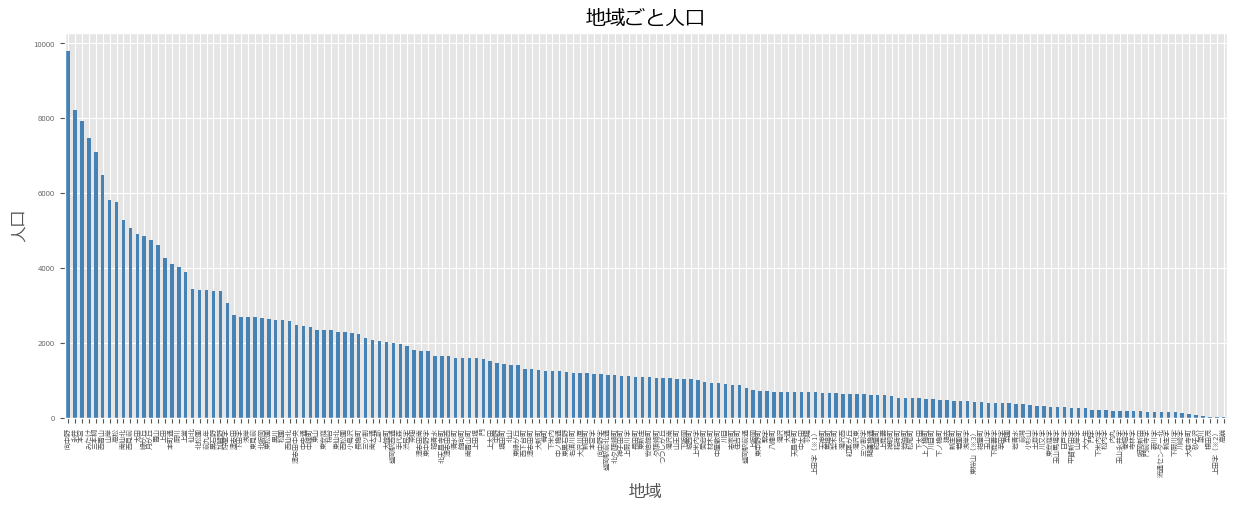

In [166]:
sorted_df.plot(
    x="area",
    y="total_population",
    kind="bar",
    figsize=(15, 5),
    fontsize=5,
    title="地域ごと人口",
    color="steelblue",
    legend=False
)

plt.xlabel("地域", fontsize=12)
plt.ylabel("人口", fontsize=12)

plt.savefig('../output/area/area_population_bar.png', bbox_inches='tight')
plt.show()

## 【クラスター分析】

In [86]:
# カラム名取得
columns = df.columns.str.strip()
print(columns)

Index(['area', 'total_population', 'male_population', 'female_population',
       'male_0_4', 'male_5_9', 'male_10_14', 'male_15_19', 'male_20_24',
       'male_25_29', 'male_30_34', 'male_35_39', 'male_40_44', 'male_45_49',
       'male_50_54', 'male_55_59', 'male_60_64', 'male_65_69', 'male_70_74',
       'male_75_79', 'male_80_84', 'male_85_89', 'male_90_plus', 'female_0_4',
       'female_5_9', 'female_10_14', 'female_15_19', 'female_20_24',
       'female_25_29', 'female_30_34', 'female_35_39', 'female_40_44',
       'female_45_49', 'female_50_54', 'female_55_59', 'female_60_64',
       'female_65_69', 'female_70_74', 'female_75_79', 'female_80_84',
       'female_85_89', 'female_90_plus', 'facility_No', 'facility_name',
       'available_days', 'facility_area_name', 'housing_No', 'housing_name',
       'housing_area_name', 'distance_m_to_nearest_housing', '男性人口', '女性人口',
       '総人口', 'male_under_15', 'male_15_64', 'male_65_plus', 'female_under_15',
       'female_15_64', 'female

### 特徴量作成

In [87]:
##公民館フラグ生成
# notna()     - 公民館と結合できなかった地域の"public_facility_name"はNaNになっているので[公民館あり：なし]=[1:0]で判定。
# astype(int) - 判定結果はTrue/Falseのbool値なので1/0のint型に型変換
df["facility_flag"] = (df["facility_name"].notna().astype(int))

In [88]:
# フラグの数と公民館データ件数があっているか確認
df["facility_flag"].sum() == df["facility_name"].notna().sum()

np.True_

### クラスタ分類

In [89]:
#---特徴量---
# 1.15歳以下人口割合
# 2.65以上人口割合
# 3.男性人口割合


# 特徴量選択
features_ratio = [
    "population_under_15_ratio",
    'population_65_plus_ratio',
    'population_male_ratio',
]
X_ratio = df[features_ratio]

# 標準化
scaler_ratio = StandardScaler()
X_ratio_scaled = scaler_ratio.fit_transform(X_ratio)

# クラスタリング
# random_state=ランダム値固定(数値は何でもOK)
model_ratio = KMeans(
    n_clusters=3,
    random_state=42 
)
clusters_ratio = model_ratio.fit_predict(X_ratio_scaled)

# 結果保存
df["cluster_ratio"] = clusters_ratio

# クラスタ特徴確認
print(
    df.groupby("cluster_ratio")[features_ratio].mean()
)

               population_under_15_ratio  population_65_plus_ratio  \
cluster_ratio                                                        
0                               0.057582                  0.453168   
1                               0.125619                  0.253552   
2                               0.078030                  0.369572   

               population_male_ratio  
cluster_ratio                         
0                           0.514128  
1                           0.477562  
2                           0.457918  


##### 解釈
- クラスタ0 : 子ども中、高齢層やや多
- クラスタ1 : 子ども多、高齢層やや少
- クラスタ2 : 子ども少、高齢層中
- （男性人口割合はあまり影響なし）

In [91]:
df["cluster_ratio"].value_counts()

cluster_ratio
2    74
1    59
0    35
Name: count, dtype: int64

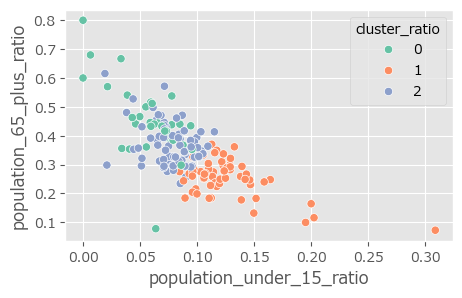

In [92]:
plt.figure(figsize=(5, 3))
sns.scatterplot(
    data=df,
    x="population_under_15_ratio",
    y="population_65_plus_ratio",
    hue="cluster_ratio",
    palette="Set2"
)

plt.show()

##### 公民館フラグを入れてみる

In [93]:
#---特徴量---
# 1.15歳以下人口割合
# 2.65以上人口割合
# 3.男性人口割合
# 4.公民館フラグ　☆追加

# 特徴量選択
features_facility = [
    "population_under_15_ratio",
    'population_65_plus_ratio',
    'population_male_ratio',
    "facility_flag"
]
X_facility= df[features_facility]

# 標準化
scaler_facility = StandardScaler()
X_facility_scaled = scaler_facility.fit_transform(X_facility)

# クラスタリング
model_facility = KMeans(
    n_clusters=3,
    random_state=42 
)
clusters_facility = model_facility.fit_predict(X_facility_scaled)

# 結果保存
df["cluster_facility"] = clusters_facility

# クラスタ特徴確認
print(
    df.groupby("cluster_facility")[features_facility].mean()
)

                  population_under_15_ratio  population_65_plus_ratio  \
cluster_facility                                                        
0                                  0.059868                  0.443301   
1                                  0.108389                  0.289284   
2                                  0.098695                  0.322093   

                  population_male_ratio  facility_flag  
cluster_facility                                        
0                              0.493727            0.0  
1                              0.466321            0.0  
2                              0.473354            1.0  


In [94]:
df["cluster_facility"].value_counts()

cluster_facility
1    98
0    60
2    10
Name: count, dtype: int64

##### 解釈
- クラスタ0 : 子ども中、高齢層やや多
- クラスタ1 : 子ども多、高齢層小
- クラスタ2 : 子ども多、高齢層中、公民館あり
- （男性人口割合はあまり影響なし）
- 少しの差だが子供が多めで高齢者層が普通くらいの地域に公民館がある（クラスタ1）
- 子ども多めで高齢層が少ない地域には公民館がない（クラスタ2）　→　クラスタ2は1より新しい子育て地域の可能性

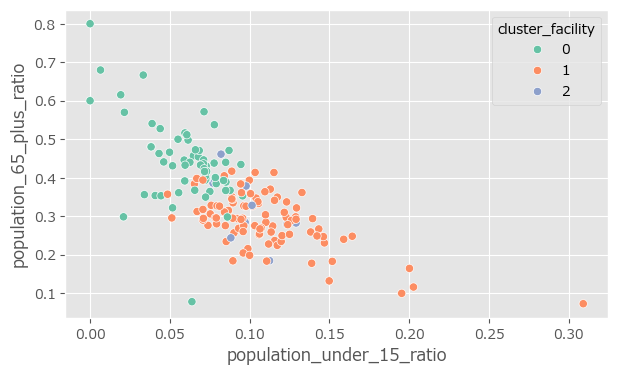

In [95]:
plt.figure(figsize=(7, 4))
sns.scatterplot(
    data=df,
    x="population_under_15_ratio",
    y="population_65_plus_ratio",
    hue="cluster_facility",
    palette="Set2"
)

plt.show()

##### 総人口を追加してみる

In [113]:
#---特徴量---
# 1.15歳以下人口割合
# 2.65以上人口割合
# 3.公民館フラグ
# 4.総人口　　　　☆追加
# ※男性人口割合は影響ないので削除した

# 特徴量選択
features_population = [
    "population_under_15_ratio",
    'population_65_plus_ratio',
#    'population_male_ratio',
    "facility_flag",
    "total_population"
]
X_population= df[features_population]

# 標準化
scaler_population = StandardScaler()
X_population_scaled = scaler_population.fit_transform(X_population)

# クラスタリング
model_population = KMeans(
    n_clusters=5,
    random_state=42 
)
clusters_population = model_population.fit_predict(X_population_scaled)

# 結果保存
df["cluster_population"] = clusters_population

# クラスタ特徴確認
print(
    df.groupby("cluster_population")[features_population].mean()
)

                    population_under_15_ratio  population_65_plus_ratio  \
cluster_population                                                        
0                                    0.075142                  0.376914   
1                                    0.111581                  0.268045   
2                                    0.039942                  0.556945   
3                                    0.098695                  0.322093   
4                                    0.152658                  0.225672   

                    facility_flag  total_population  
cluster_population                                   
0                             0.0        895.602740  
1                             0.0       1892.833333  
2                             0.0        283.722222  
3                             1.0       2882.700000  
4                             0.0       5676.538462  


##### 解釈
- クラスタ0 : 子ども多め、高齢層少なめ、人口少ない
    - （極端に子どもが多かったり高齢者が多かったりしない人口少なめの地域。多数派地域）
- クラスタ1 : 子ども多め、高齢層少ない、人口中の小の半分
    - （多数は地域よりやや子どもが多く、高齢者は少ない、人口は倍くらいある地域。2番目の多数派）
- クラスタ2 : 子ども少、高齢層多め、人口めっちゃ少ない
    - （人口が少なく、高齢化も進む地域）
- クラスタ3 : 子ども多め、高齢層少なめ、公民館あり、人口中の小
    - （中心地域よりは人口規模は半分だが子どもも多く、公民館もある地域）
- クラスタ4 : 子ども多、高齢層少ない、人口多い
    - （子どもが多く、高齢者が少ない、人口の多い中心地域）
- 公民館フラグので比較すると、クラスタ1は子ども比率、高齢比率が同じだが人口が半分で公民館がない
- クラスタ3は比率はクラスタ1と同程度だが平均人口が約1.5倍あり公民館がある

In [114]:
df["cluster_population"].value_counts()

cluster_population
0    73
1    54
2    18
4    13
3    10
Name: count, dtype: int64

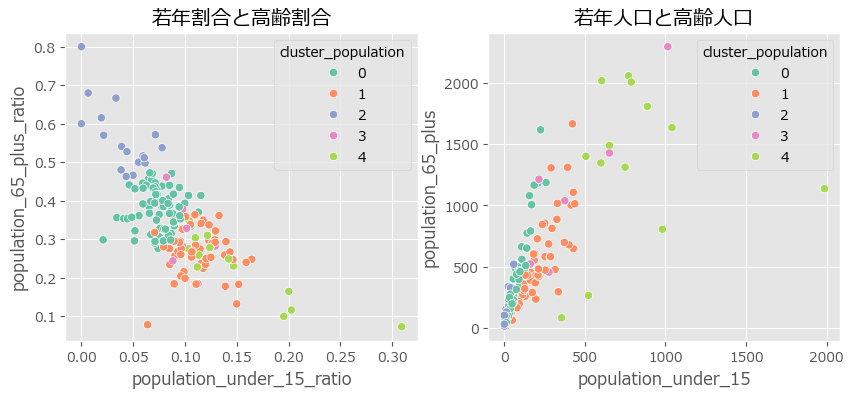

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.scatterplot(
    ax=axes[0],
    data=df,
    x="population_under_15_ratio",
    y="population_65_plus_ratio",
    hue="cluster_population",
    palette="Set2"
)

sns.scatterplot(
    ax=axes[1],
    data=df,
    x="population_under_15",
    y="population_65_plus",
    hue="cluster_population",
    palette="Set2"
)


axes[0].set_title("若年割合と高齢割合")
axes[1].set_title("若年人口と高齢人口")
plt.show()

##### 公民館フラグを抜いてみる

In [115]:
#---特徴量---
# 1.15歳以下人口割合
# 2.65以上人口割合
# 3.総人口　　　　

# 特徴量選択
features_population_without_facility = [
    "population_under_15_ratio",
    'population_65_plus_ratio',
    "total_population"
]
X_population_without_facility= df[features_population_without_facility]

# 標準化
scaler_population_without_facility = StandardScaler()
X_population_without_facility_scaled = scaler_population_without_facility.fit_transform(X_population_without_facility)

# クラスタリング
model_population_without_facility = KMeans(
    n_clusters=5,
    random_state=42 
)
clusters_population_without_facility = model_population_without_facility.fit_predict(X_population_without_facility_scaled)

# 結果保存
df["cluster_population_without_facility"] = clusters_population_without_facility

# クラスタ特徴確認
print(
    df.groupby("cluster_population_without_facility")[features_population_without_facility].mean()
)

                                     population_under_15_ratio  \
cluster_population_without_facility                              
0                                                     0.076808   
1                                                     0.131397   
2                                                     0.135220   
3                                                     0.095508   
4                                                     0.040269   

                                     population_65_plus_ratio  \
cluster_population_without_facility                             
0                                                    0.374317   
1                                                    0.227876   
2                                                    0.251554   
3                                                    0.310015   
4                                                    0.550844   

                                     total_population  
cluster_population_withou

In [119]:
##公民館がある地域はそれぞれのモデルでどう分類されたかチェックしてみる
# cluster_ratio      - 「15歳以下人口割合」「65歳以上人口割合」「男性人口割合」
# cluster_facility   - 「15歳以下人口割合」「65歳以上人口割合」「男性人口割合」「公民館フラグ」
# cluster_population - 「15歳以下人口割合」「65歳以上人口割合」「公民館フラグ」「総人口」
# cluster_population_without_facility - 「15歳以下人口割合」「65歳以上人口割合」「総人口」
sorted_df = df.sort_values("distance_m_to_nearest_housing", ascending=False)
sorted_df.loc[
    sorted_df["facility_flag"] == 1,
    ["area", "facility_name", "distance_m_to_nearest_housing", "total_population",
     "cluster_ratio", "cluster_facility", 'cluster_population', "cluster_population_without_facility"]
    ]

,area,facility_name,distance_m_to_nearest_housing,total_population,cluster_ratio,cluster_facility,cluster_population,cluster_population_without_facility
14,下飯岡,盛岡市飯岡地区公民館,2758.713220,1033.0,2,2,3,0
118,津志田中央,盛岡市見前地区公民館,2265.134495,2471.0,1,2,3,1
130,東松園,盛岡市松園地区公民館,2069.572058,2632.0,2,2,3,0
2,愛宕町,盛岡市中央公民館,2036.267547,957.0,1,2,3,3
60,松尾町,盛岡市河南公民館,1546.762097,537.0,2,2,3,0
7,永井,盛岡市都南公民館,1535.108902,8232.0,1,2,3,2
65,上田,盛岡市上田公民館,1525.622140,4261.0,1,2,3,3
8,乙部,盛岡市乙部地区公民館,1028.067441,2051.0,0,2,3,0
85,西見前,盛岡市見前南地区公民館,366.193386,5057.0,1,2,3,2
141,南青山町,盛岡市西部公民館,254.341376,1596.0,2,2,3,3


#### 所感
- "公民館分析"にて「ほとんどの公民館は約2km以内に市営住宅が存在する」結果から「地域全体で見ても、公民館のあるなしが特徴となっているのでは？」という仮説が生まれた
- 特徴量に「公民館フラグ」を入れた場合は公民館がある地域のみのクラスターが生成される結果となった
    - その他の特徴量を比較しても公民館がない他のクラスターとは異なる地域の特徴を持っていると言えると思う（平均的に見て15歳以下人口割合が大きいとか）
    - とはいえ、クラスタ分類に「公民館フラグ」が大きな影響を与えていることも確か

In [150]:
#公民館がある地域だけ抽出
dropna_df = df.dropna(subset=['facility_name'])

In [148]:
"""
for cluster in sorted(dropna_df["cluster_population_without_facility"].unique()):

    cluster_df = dropna_df[dropna_df["cluster_population_without_facility"] == cluster]

    plt.figure(figsize=(4, 4))

    plt.bar(
        cluster_df["facility_name"],
        cluster_df["population_under_15_ratio"],
        label="15歳以下",
        color="salmon"
    )
    plt.bar(
        cluster_df["facility_name"],
        cluster_df["population_15_64_ratio"],
        bottom=cluster_df["population_under_15_ratio"],
        label="15歳-64歳",
        color="lightblue"
    )
    plt.bar(
        cluster_df["facility_name"],
        cluster_df["population_65_plus_ratio"],
        bottom=cluster_df["population_under_15_ratio"]+cluster_df["population_15_64_ratio"],
        label="65歳以上",
        color="thistle"
    )

    plt.title(f"Cluster {cluster}")

    #plt.xlabel("地域")
    #plt.ylabel("人口")

    #plt.xticks(rotation=45)

    #plt.grid(axis="y")

plt.show()
"""

'\nfor cluster in sorted(dropna_df["cluster_population_without_facility"].unique()):\n\n    cluster_df = dropna_df[dropna_df["cluster_population_without_facility"] == cluster]\n\n    plt.figure(figsize=(4, 4))\n\n    plt.bar(\n        cluster_df["facility_name"],\n        cluster_df["population_under_15_ratio"],\n        label="15歳以下",\n        color="salmon"\n    )\n    plt.bar(\n        cluster_df["facility_name"],\n        cluster_df["population_15_64_ratio"],\n        bottom=cluster_df["population_under_15_ratio"],\n        label="15歳-64歳",\n        color="lightblue"\n    )\n    plt.bar(\n        cluster_df["facility_name"],\n        cluster_df["population_65_plus_ratio"],\n        bottom=cluster_df["population_under_15_ratio"]+cluster_df["population_15_64_ratio"],\n        label="65歳以上",\n        color="thistle"\n    )\n\n    plt.title(f"Cluster {cluster}")\n\n    #plt.xlabel("地域")\n    #plt.ylabel("人口")\n\n    #plt.xticks(rotation=45)\n\n    #plt.grid(axis="y")\n\nplt.show()\n'

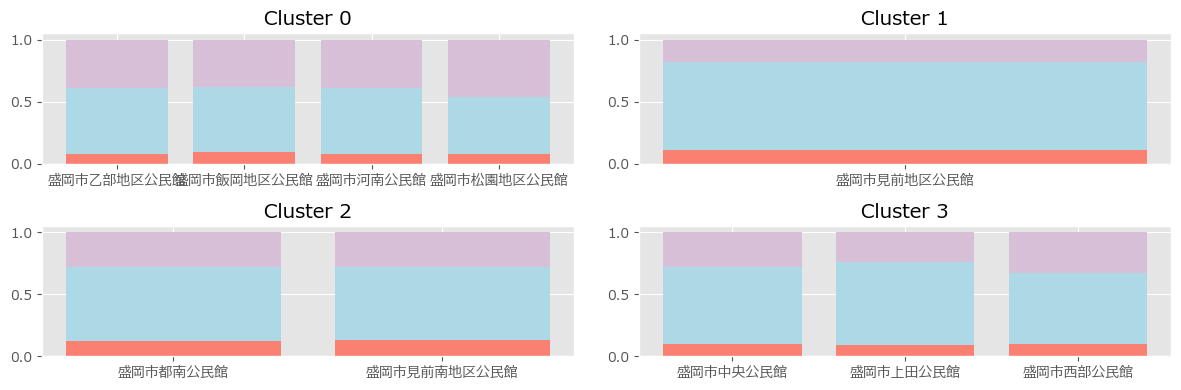

In [168]:
# 公民館のある地域の、特徴量に「公民館フラグ」がない場合に分類されたクラスタごとに人口比率のグラフを作成

clusters = sorted(dropna_df["cluster_population_without_facility"].unique())

fig, axes = plt.subplots(2, 2, figsize=(12, 4))

for i, cluster in enumerate(clusters):

    cluster_df = dropna_df[dropna_df["cluster_population_without_facility"] == cluster]

    # グラフの位置算出
    ax = axes[i // 2, i % 2]

    ax.bar(
        cluster_df["facility_name"],
        cluster_df["population_under_15_ratio"],
        label="15歳以下",
        color="salmon"
    )
    ax.bar(
        cluster_df["facility_name"],
        cluster_df["population_15_64_ratio"],
        bottom=cluster_df["population_under_15_ratio"],
        label="15歳-64歳",
        color="lightblue"
    )
    ax.bar(
        cluster_df["facility_name"],
        cluster_df["population_65_plus_ratio"],
        bottom=cluster_df["population_under_15_ratio"]+cluster_df["population_15_64_ratio"],
        label="65歳以上",
        color="thistle"
    )

    ax.set_title(f"Cluster {cluster}")

# 重なって表示されない
plt.tight_layout()
plt.savefig('../output/cluster/public_facilities_age_composition_by_cluster.png', bbox_inches='tight')
plt.show()

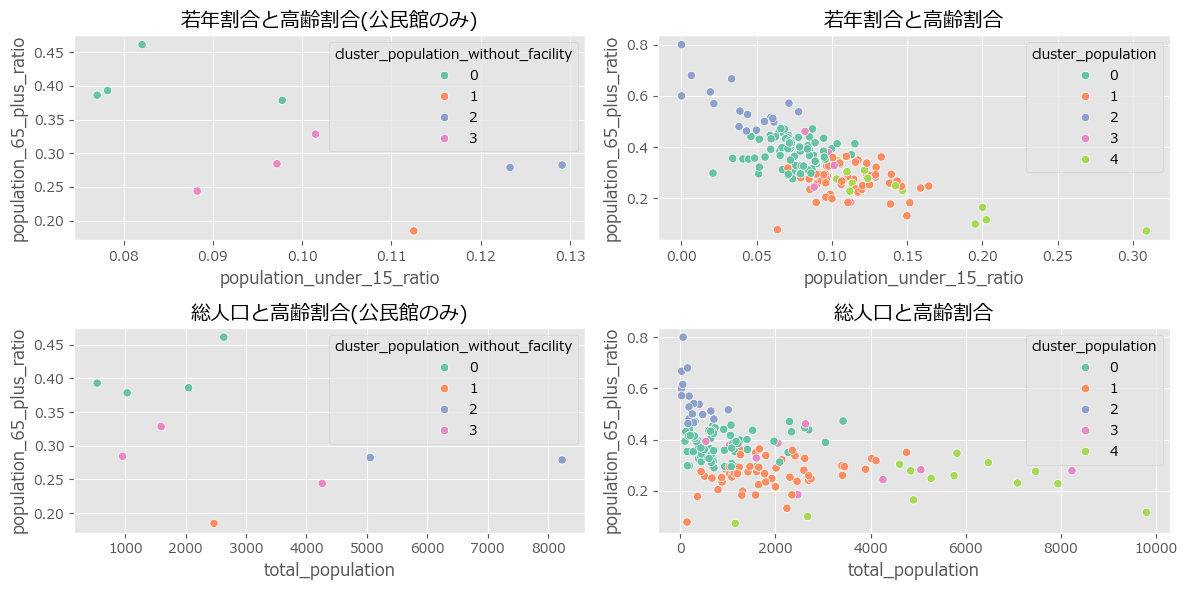

In [167]:
# 公民館のみと地域全体の分布比較
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# x軸：15歳以下人口割合
# y軸：65歳以上人口割合
sns.scatterplot(
    ax=axes[0][0],
    data=dropna_df,
    x="population_under_15_ratio",
    y="population_65_plus_ratio",
    hue="cluster_population_without_facility",
    palette="Set2"
)
sns.scatterplot(
    ax=axes[0][1],
    data=df,
    x="population_under_15_ratio",
    y="population_65_plus_ratio",
    hue="cluster_population",
    palette="Set2"
)

# x軸：総人口
# y軸：65歳以上人口割合
sns.scatterplot(
    ax=axes[1][0],
    data=dropna_df,
    x="total_population",
    y="population_65_plus_ratio",
    hue="cluster_population_without_facility",
    palette="Set2"
)
sns.scatterplot(
    ax=axes[1][1],
    data=df,
    x="total_population",
    y="population_65_plus_ratio",
    hue="cluster_population",
    palette="Set2"
)

axes[0][0].set_title("若年割合と高齢割合(公民館のみ)")
axes[0][1].set_title("若年割合と高齢割合")
axes[1][0].set_title("総人口と高齢割合(公民館のみ)")
axes[1][1].set_title("総人口と高齢割合")

plt.tight_layout()
plt.savefig('../output/cluster/public_hall_location_pattern.png', bbox_inches='tight')
plt.show()

#### 所感
- 公民館がある地域の「15歳以下人口割合」は範囲が0.07-0.13、「65歳以上人口割合」は範囲が0.18-0.46くらいでどちらも地域全体のボリュームゾーン
    - だから「公民館のあるなし」が特徴として強調された可能性
- 逆に、子供の割合が低く高齢者の割合が高い「高齢化地域」には公民館は建設されず、
- 子どもの割合が極端に高く高齢者割合が低い「中心地域」にも公民館は建設されていないことがわかる。
- 公民館ある地域10件中6件は総人口2,000人以上で、地域全体で見たら「人口が多い地域」の部類に入ると思う
- 公民館がある地域は「高齢化率が極端に高くない」「人口は多い」タイプの地域
- （子どもの割合は全体と比較して高めの地域とは言えないかな）
- 　→　公民館は新しく建設されるイメージがないので、昔から人口比がそんなに変わらずに繫栄している地域なのかな
- 　　　（高齢化が極端に進んでいないので、公民館が建設されたときと比較して、子どもの割合が減っているわけではない）
- 　　　（総人口もそこそこいるので、中心地域に人口を吸われ切らない、ベッドタウン的な立ち位置の地域かもしれない